In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
df = pd.read_csv('exams.csv')

In [44]:
df.head(30)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68
5,female,group D,high school,standard,none,63,77,76
6,female,group A,bachelor's degree,standard,none,62,59,63
7,male,group E,some college,standard,completed,93,88,84
8,male,group D,high school,standard,none,63,56,65
9,male,group C,some college,free/reduced,none,47,42,45


In [45]:
df['pass_fail'] = df['math score'].apply(
    lambda x: 'pass' if x>=40 else 'fail'
)

In [46]:
df.head(8)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,male,group A,high school,standard,completed,67,67,63,pass
1,female,group D,some high school,free/reduced,none,40,59,55,pass
2,male,group E,some college,free/reduced,none,59,60,50,pass
3,male,group B,high school,standard,none,77,78,68,pass
4,male,group E,associate's degree,standard,completed,78,73,68,pass
5,female,group D,high school,standard,none,63,77,76,pass
6,female,group A,bachelor's degree,standard,none,62,59,63,pass
7,male,group E,some college,standard,completed,93,88,84,pass


In [47]:
df['test preparation course'].value_counts()

test preparation course
none         665
completed    335
Name: count, dtype: int64

In [48]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
pass_fail                      0
dtype: int64

In [49]:
df.describe()

,math score,reading score,writing score
count,1000.000000,1000.000000,1000.000000
mean,66.396000,69.002000,67.738000
std,15.402871,14.737272,15.600985
min,13.000000,27.000000,23.000000
25%,56.000000,60.000000,58.000000
50%,66.500000,70.000000,68.000000
75%,77.000000,79.000000,79.000000
max,100.000000,100.000000,100.000000


In [50]:
df.shape

(1000, 9)

In [51]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,male,group A,high school,standard,completed,67,67,63,pass
1,female,group D,some high school,free/reduced,none,40,59,55,pass
2,male,group E,some college,free/reduced,none,59,60,50,pass
3,male,group B,high school,standard,none,77,78,68,pass
4,male,group E,associate's degree,standard,completed,78,73,68,pass


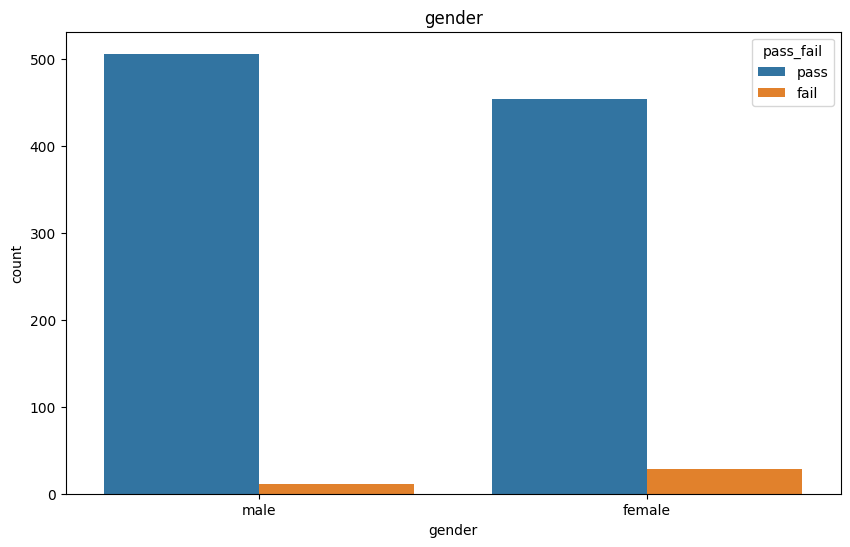

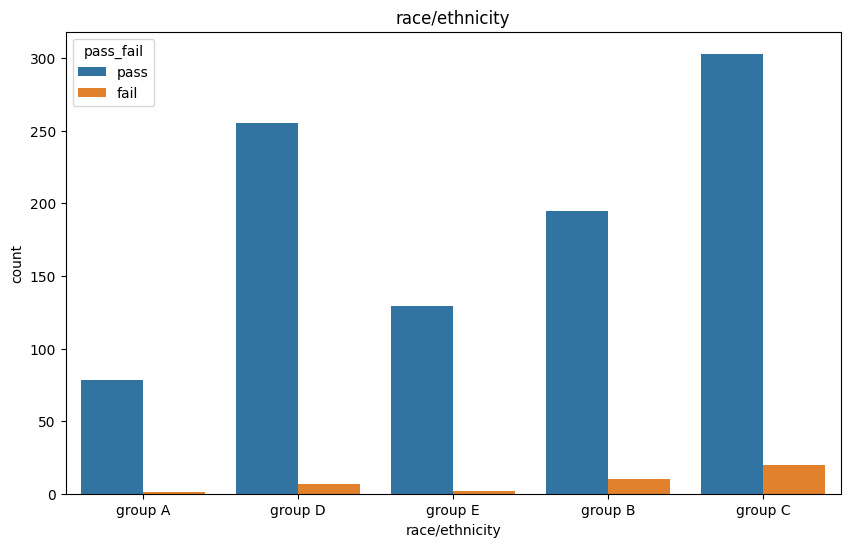

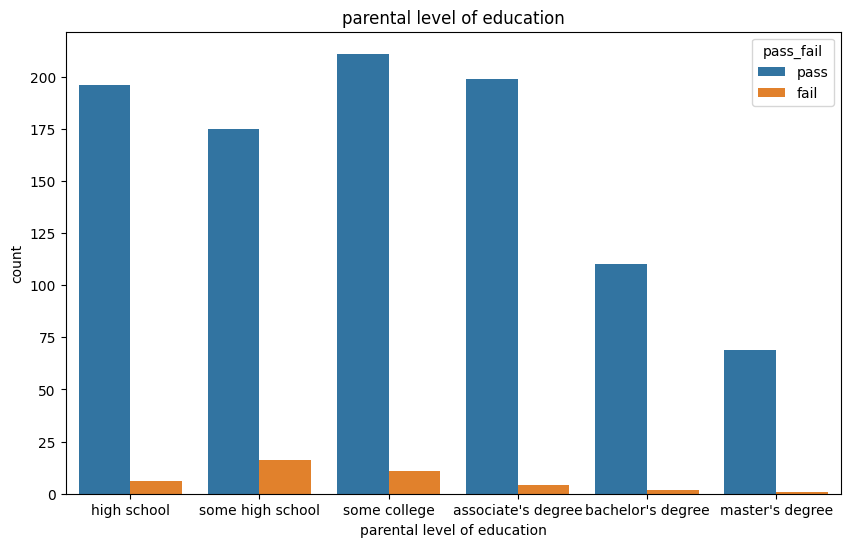

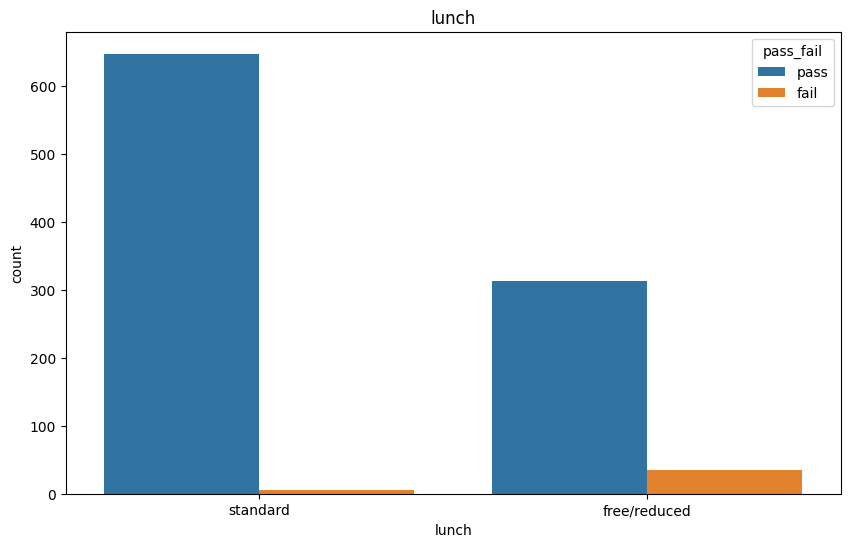

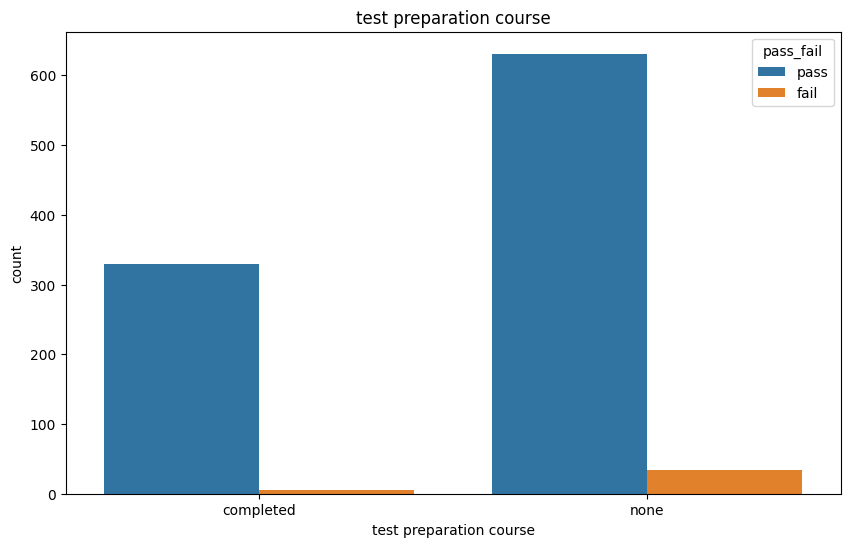

In [52]:
def count_plot():
    cols = ['gender' , 'race/ethnicity' , 'parental level of education' , 'lunch' , 'test preparation course' ,]

    for col in cols:
        plt.figure(figsize=(10,6)) 
        sns.countplot(x=df[col] , hue = df['pass_fail'])
        plt.title(col)
        plt.show() 

count_plot()

In [53]:
# cross_tab = pd.crosstab(
#     df['test preparation course'],
#     df['pass_fail'],
#     normalize='index'
# ) * 100

# cross_tab

In [54]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,male,group A,high school,standard,completed,67,67,63,pass
1,female,group D,some high school,free/reduced,none,40,59,55,pass
2,male,group E,some college,free/reduced,none,59,60,50,pass
3,male,group B,high school,standard,none,77,78,68,pass
4,male,group E,associate's degree,standard,completed,78,73,68,pass


<Axes: >

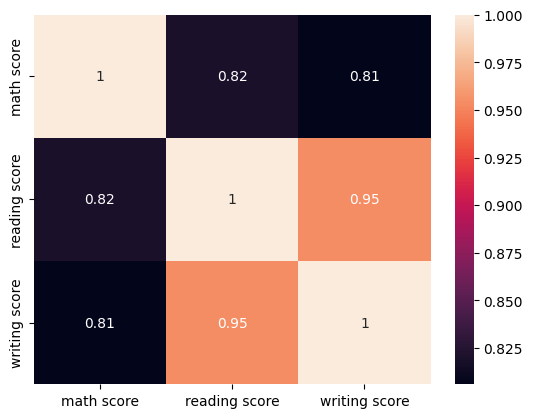

In [55]:

sns.heatmap(df.corr(numeric_only=True) , annot=True)

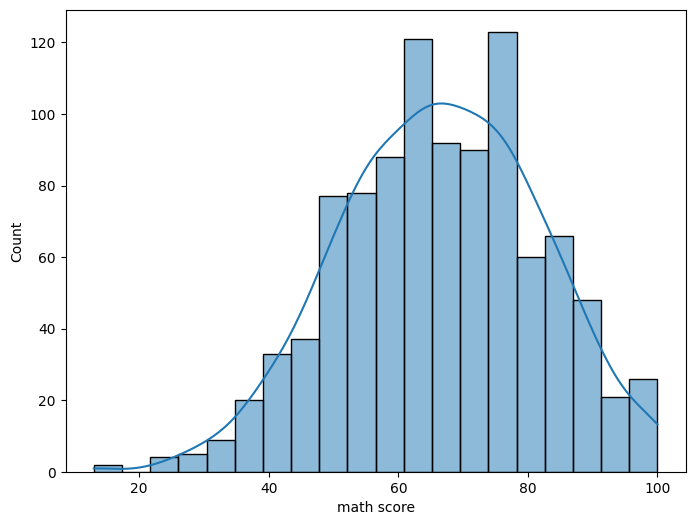

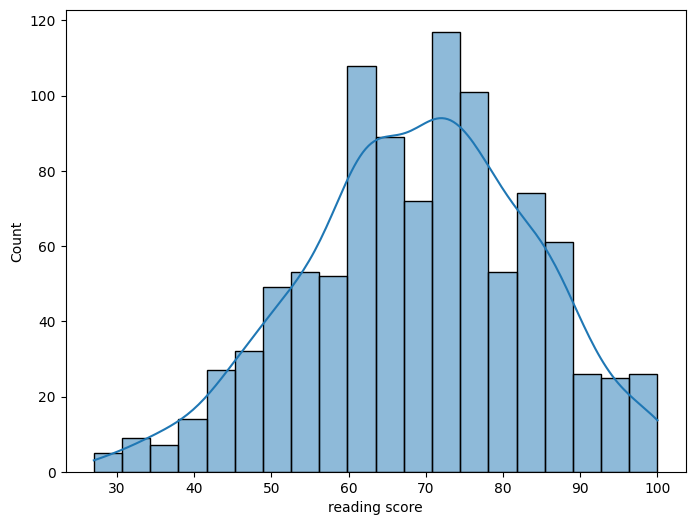

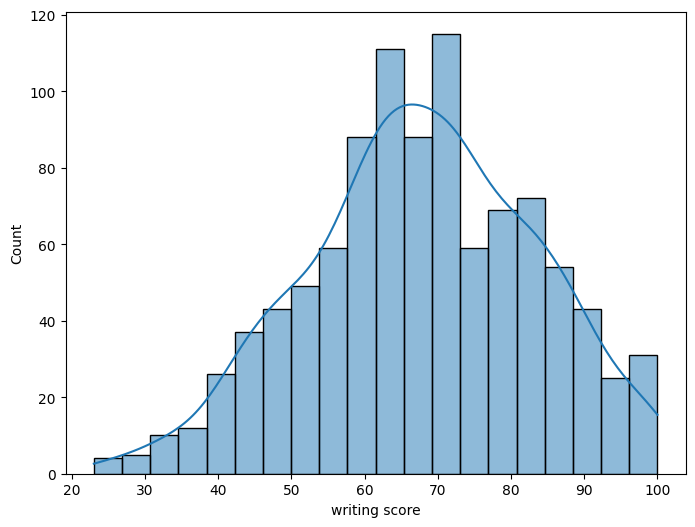

In [56]:
numeric_only = ['math score' , 'reading score' , 'writing score']
for column in numeric_only:
    plt.figure(figsize=(8,6))
    sns.histplot(df[column] , kde=True , bins = 20)

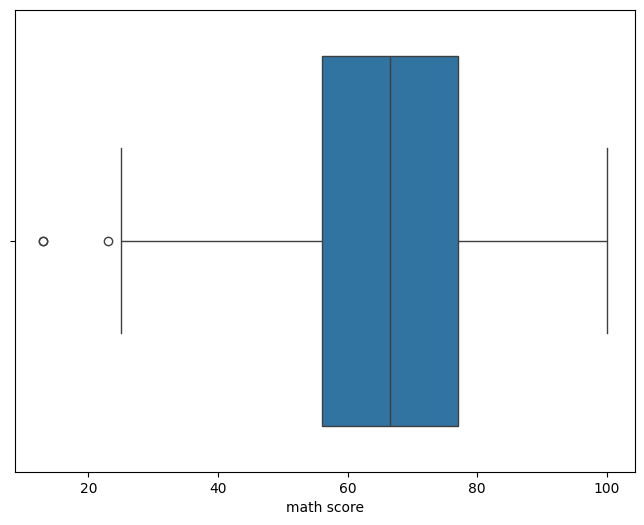

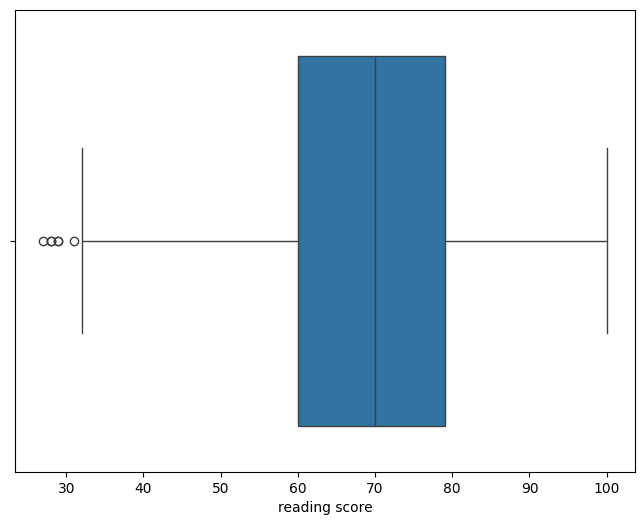

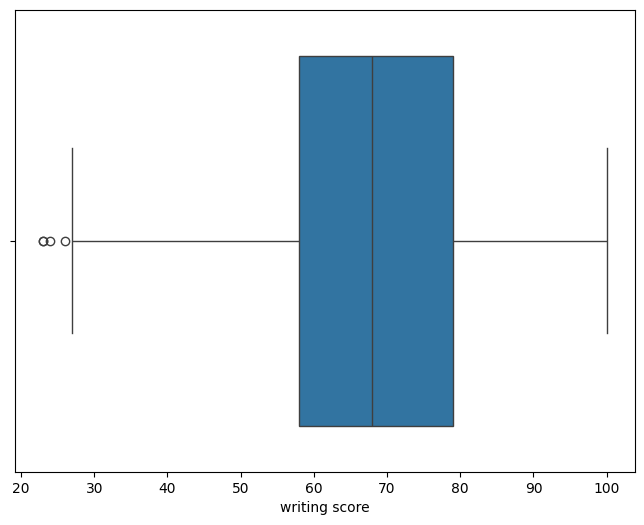

In [57]:
for column in numeric_only:
    plt.figure(figsize=(8,6))
    sns.boxplot(x = df[column])

In [58]:
#  Remove outlier


for col in numeric_only:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

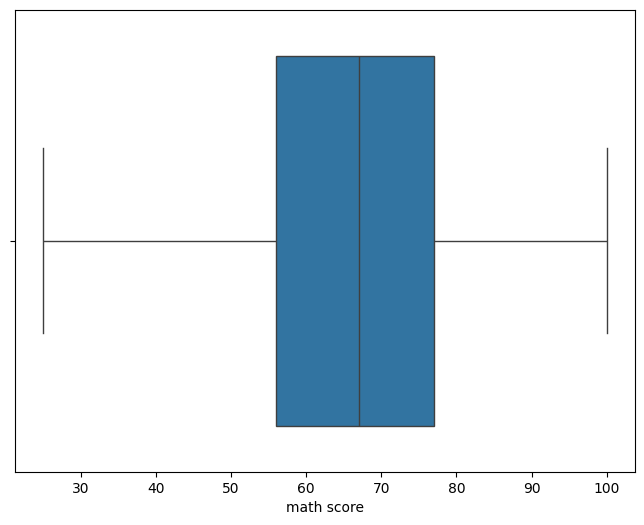

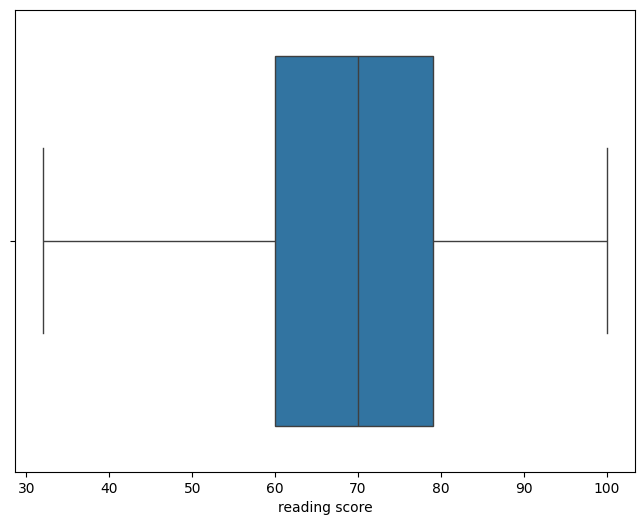

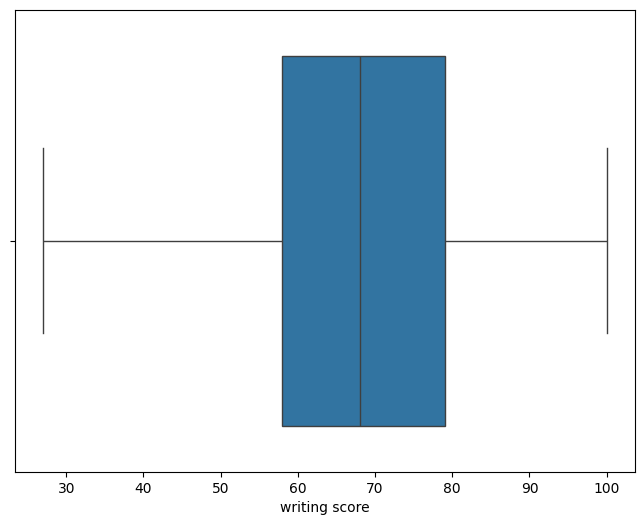

In [59]:
for column in numeric_only:
    plt.figure(figsize=(8,6))
    sns.boxplot(x = df[column])

In [60]:
df.shape

(992, 9)

In [61]:
x = df.drop(columns=['pass_fail' , 'math score'])
y = df['pass_fail']

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,male,group A,high school,standard,completed,67,67,63,pass
1,female,group D,some high school,free/reduced,none,40,59,55,pass
2,male,group E,some college,free/reduced,none,59,60,50,pass
3,male,group B,high school,standard,none,77,78,68,pass
4,male,group E,associate's degree,standard,completed,78,73,68,pass


In [62]:
df_cleaned = df.copy()

In [63]:
df_cleaned.drop_duplicates(inplace=True)

In [64]:
df_cleaned.shape

(991, 9)

In [65]:
df_cleaned.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
pass_fail                      object
dtype: object

In [66]:
df_cleaned['gender'].value_counts()

gender
male      512
female    479
Name: count, dtype: int64

# Label Encoding

In [67]:
df_cleaned['gender'] = df['gender'].map(
    {
        "male":0,
        "female":1
    }
)

In [68]:
df_cleaned.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,0,group A,high school,standard,completed,67,67,63,pass
1,1,group D,some high school,free/reduced,none,40,59,55,pass
2,0,group E,some college,free/reduced,none,59,60,50,pass
3,0,group B,high school,standard,none,77,78,68,pass
4,0,group E,associate's degree,standard,completed,78,73,68,pass


In [69]:
df_cleaned['race/ethnicity'].value_counts()

race/ethnicity
group C    319
group D    261
group B    202
group E    130
group A     79
Name: count, dtype: int64

In [70]:
# one hot coding

df_cleaned = pd.get_dummies(df_cleaned , columns=['race/ethnicity'] , drop_first=True)

In [71]:
df_cleaned.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E
0,0,high school,standard,completed,67,67,63,pass,False,False,False,False
1,1,some high school,free/reduced,none,40,59,55,pass,False,False,True,False
2,0,some college,free/reduced,none,59,60,50,pass,False,False,False,True
3,0,high school,standard,none,77,78,68,pass,True,False,False,False
4,0,associate's degree,standard,completed,78,73,68,pass,False,False,False,True


In [72]:
df_cleaned['parental level of education'].value_counts()

parental level of education
some college          217
high school           201
associate's degree    201
some high school      190
bachelor's degree     112
master's degree        70
Name: count, dtype: int64

In [73]:
# one hot coding on parantal level of education

df_cleaned = pd.get_dummies(df_cleaned , columns=['parental level of education'] , drop_first=True)
df_cleaned.head()

,gender,lunch,test preparation course,math score,reading score,writing score,pass_fail,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,standard,completed,67,67,63,pass,False,False,False,False,False,True,False,False,False
1,1,free/reduced,none,40,59,55,pass,False,False,True,False,False,False,False,False,True
2,0,free/reduced,none,59,60,50,pass,False,False,False,True,False,False,False,True,False
3,0,standard,none,77,78,68,pass,True,False,False,False,False,True,False,False,False
4,0,standard,completed,78,73,68,pass,False,False,False,True,False,False,False,False,False


In [74]:
df_cleaned['test preparation course'].value_counts()

test preparation course
none         658
completed    333
Name: count, dtype: int64

In [75]:
# label encoding

df_cleaned['test preparation course'] = df_cleaned['test preparation course'].map(
    {
        "none":0,
        "completed":1
    }
)
df_cleaned.head()

,gender,lunch,test preparation course,math score,reading score,writing score,pass_fail,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,standard,1,67,67,63,pass,False,False,False,False,False,True,False,False,False
1,1,free/reduced,0,40,59,55,pass,False,False,True,False,False,False,False,False,True
2,0,free/reduced,0,59,60,50,pass,False,False,False,True,False,False,False,True,False
3,0,standard,0,77,78,68,pass,True,False,False,False,False,True,False,False,False
4,0,standard,1,78,73,68,pass,False,False,False,True,False,False,False,False,False


In [76]:
df_cleaned['lunch'].value_counts()

lunch
standard        651
free/reduced    340
Name: count, dtype: int64

In [77]:
df_cleaned['lunch'] = df_cleaned['lunch'].map(
    {
        "standard":0,
        "free/reduced":1
    }
)
df_cleaned.head()

,gender,lunch,test preparation course,math score,reading score,writing score,pass_fail,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,1,67,67,63,pass,False,False,False,False,False,True,False,False,False
1,1,1,0,40,59,55,pass,False,False,True,False,False,False,False,False,True
2,0,1,0,59,60,50,pass,False,False,False,True,False,False,False,True,False
3,0,0,0,77,78,68,pass,True,False,False,False,False,True,False,False,False
4,0,0,1,78,73,68,pass,False,False,False,True,False,False,False,False,False


In [78]:
# isme ek problem thi hmara pass_fail matlab target categorical tha isliye true false .astype(int) direct isko 0,1 ni kr para tha lekin is code se sirf true/false hi 0,1 me ho jayege.

bool_cols = df_cleaned.select_dtypes(
    include='bool'
).columns

df_cleaned[bool_cols] = (
    df_cleaned[bool_cols]
    .astype(int)
)

df_cleaned.head()

,gender,lunch,test preparation course,math score,reading score,writing score,pass_fail,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,1,67,67,63,pass,0,0,0,0,0,1,0,0,0
1,1,1,0,40,59,55,pass,0,0,1,0,0,0,0,0,1
2,0,1,0,59,60,50,pass,0,0,0,1,0,0,0,1,0
3,0,0,0,77,78,68,pass,1,0,0,0,0,1,0,0,0
4,0,0,1,78,73,68,pass,0,0,0,1,0,0,0,0,0


In [79]:
#  pass_fail ko 0,1 bnana upar agar pehle hi bnaleta to direct saro ko .astype(int) krke true false bhi intezer type me krr deta per koi ni ab krr deta hu vo bhi shi logic tha.

df_cleaned['pass_fail'] = df_cleaned['pass_fail'].map(
    {
        "fail":0,
        "pass":1
    }
)

In [80]:
# StandardScaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['math score' , 'reading score' , 'writing score']

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

df_cleaned

,gender,lunch,test preparation course,math score,reading score,writing score,pass_fail,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,0,1,0.022945,-0.158281,-0.328835,1,0,0,0,0,0,1,0,0,0
1,1,1,0,-1.772195,-0.715252,-0.853807,1,0,0,1,0,0,0,0,0,1
2,0,1,0,-0.508948,-0.645631,-1.181914,1,0,0,0,1,0,0,0,1,0
3,0,0,0,0.687812,0.607553,-0.000728,1,1,0,0,0,0,1,0,0,0
4,0,0,1,0.754298,0.259447,-0.000728,1,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0.421865,0.050583,-0.197593,1,0,1,0,0,0,1,0,0,0
996,0,1,1,1.219705,1.512631,1.574186,1,0,0,1,0,0,0,0,0,0
997,1,1,0,-2.304088,-2.386164,-1.772507,0,0,1,0,0,0,0,0,0,1
998,1,0,0,0.421865,0.329068,0.917971,1,0,1,0,0,0,0,0,1,0


In [81]:
df_cleaned.columns

Index(['gender', 'lunch', 'test preparation course', 'math score',
       'reading score', 'writing score', 'pass_fail', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school'],
      dtype='object')

In [82]:
# Feature Extraction

#_______________________________
# pearson correlation calculation
#_______________________________

from scipy.stats import pearsonr

# List of features to check against target

selected_feature = [
    'gender', 'lunch', 'test preparation course', 'math score',
       'reading score', 'writing score', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       "parental level of education_bachelor's degree",
       'parental level of education_high school',
       "parental level of education_master's degree",
       'parental level of education_some college',
       'parental level of education_some high school'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['pass_fail'])[0]
    for feature in selected_feature
}

correlation_df = pd.DataFrame(list(correlations.items()), columns = ['Feature' , 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
3,math score,0.409598
4,reading score,0.339377
5,writing score,0.326093
2,test preparation course,0.075406
9,race/ethnicity_group E,0.040398
8,race/ethnicity_group D,0.037187
10,parental level of education_bachelor's degree,0.032263
12,parental level of education_master's degree,0.030327
11,parental level of education_high school,0.026141
13,parental level of education_some college,0.005965


In [83]:
df_cleaned.columns

Index(['gender', 'lunch', 'test preparation course', 'math score',
       'reading score', 'writing score', 'pass_fail', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school'],
      dtype='object')

In [84]:
# CHI-SQUARE TEST [ye catgory data aur target ke beech relation btata he agar relation he to rakho vo column agar ni to drop]


cat_features = [
    'gender','lunch','test preparation course','race/ethnicity_group B','race/ethnicity_group C',
    "race/ethnicity_group D','race/ethnicity_group E","parental level of education_bachelor's degree",
    'parental level of education_high school',"parental level of education_master's degree",
    'parental level of education_some college','parental level of education_some high school'
]

In [85]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

cat_features = [
    'gender',
    'lunch',
    'test preparation course',
    'race/ethnicity_group B',
    'race/ethnicity_group C',
    'race/ethnicity_group D',
    'race/ethnicity_group E',
    "parental level of education_bachelor's degree",
    'parental level of education_high school',
    "parental level of education_master's degree",
    'parental level of education_some college',
    'parental level of education_some high school'
]

chi2_results = {}

for col in cat_features:

    contingency = pd.crosstab(
        df_cleaned[col],
        df_cleaned['pass_fail']
    )

    chi2_stat, p_val, _, _ = (
        chi2_contingency(contingency)
    )

    decision = (
        'Keep Feature'
        if p_val < 0.05
        else 'Drop Feature'
    )

    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(
    chi2_results
).T

chi2_df.sort_values(by='p_value')

,chi2_statistic,p_value,Decision
lunch,38.299863,0.0,Keep Feature
parental level of education_some high school,15.853512,0.000068,Keep Feature
gender,7.93508,0.004849,Keep Feature
test preparation course,4.791934,0.028593,Keep Feature
race/ethnicity_group C,4.30642,0.037969,Keep Feature
race/ethnicity_group E,1.026735,0.310927,Drop Feature
race/ethnicity_group D,0.945856,0.330776,Drop Feature
parental level of education_bachelor's degree,0.547653,0.459278,Drop Feature
parental level of education_master's degree,0.37715,0.539132,Drop Feature
parental level of education_high school,0.367128,0.544574,Drop Feature


In [86]:
df.head(1)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,pass_fail
0,male,group A,high school,standard,completed,67,67,63,pass


In [87]:
final_df = df_cleaned[['gender','race/ethnicity_group C','parental level of education_some high school','lunch','test preparation course','reading score','writing score']]
final_df.head()

,gender,race/ethnicity_group C,parental level of education_some high school,lunch,test preparation course,reading score,writing score
0,0,0,0,0,1,-0.158281,-0.328835
1,1,0,1,1,0,-0.715252,-0.853807
2,0,0,0,1,0,-0.645631,-1.181914
3,0,0,0,0,0,0.607553,-0.000728
4,0,0,0,0,1,0.259447,-0.000728


In [88]:
X = final_df

y = df_cleaned['pass_fail']

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [90]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(792, 7)
(199, 7)
(792,)
(199,)


In [91]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [92]:
y_pred = model.predict(X_test)

In [93]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.9547738693467337


In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[  1   5]
 [  4 189]]


In [95]:
df_cleaned['pass_fail'].value_counts()

pass_fail
1    957
0     34
Name: count, dtype: int64

In [96]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [97]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But

In [98]:
y_pred = model.predict(X_test)

In [99]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.9597989949748744


In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[  2   5]
 [  3 189]]


In [101]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.97      0.98      0.98       192

    accuracy                           0.96       199
   macro avg       0.69      0.64      0.66       199
weighted avg       0.95      0.96      0.96       199



In [102]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(accuracy)

0.9597989949748744
